In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
df = pd.read_csv('/content/uber.csv')

##[1]Preprocessing the dataset

In [ ]:
df = df.dropna()
df = df[df['fare_amount'] > 0]


##[2]Identifying and removing the outliers

In [ ]:
plt.boxplot(df['fare_amount'])
plt.title("Fare Outliers")
plt.show()


NameError: name 'plt' is not defined

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fare_amount'] >= Q1 - 1.5*IQR) &
        (df['fare_amount'] <= Q3 + 1.5*IQR)]


##[3]Checking the correlation

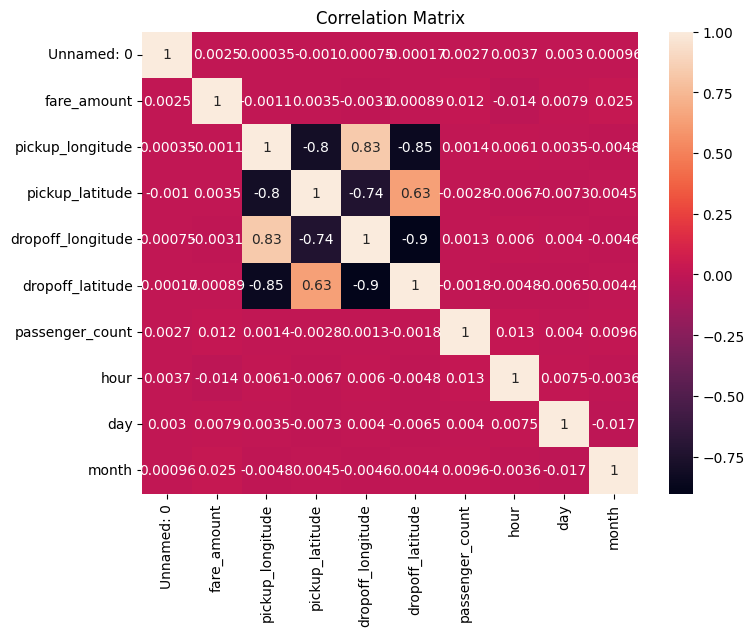

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


##[4]Regression

In [ ]:
X = df[['pickup_latitude',
        'pickup_longitude',
        'dropoff_latitude',
        'dropoff_longitude']]

y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [ ]:
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)


In [ ]:
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)


##[5]Evaluating models

In [ ]:
def evaluate(name, y_true, y_pred):
    print(name)
    print("R2:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print()


In [ ]:
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Ridge Regression", y_test, ridge_pred)
evaluate("Lasso Regression", y_test, lasso_pred)


Linear Regression
R2: -0.00021822086121803252
RMSE: 4.193231020838555

Ridge Regression
R2: -0.00021822081200073562
RMSE: 4.193231020735388

Lasso Regression
R2: -0.0001991591447580987
RMSE: 4.193191064277114



In [ ]:
[6] Correlation

In [ ]:
import pandas as pd
data= {
    'Age': [22,25,47,52,46],
    'Salary': [10000,20000,30000,40000,50000],
    'Experience': [1,3,20,25,22],
    'Score': [60,65,85,90,88]
}
df= pd.DataFrame(data)

In [ ]:
corr = df.corr()

<Axes: >

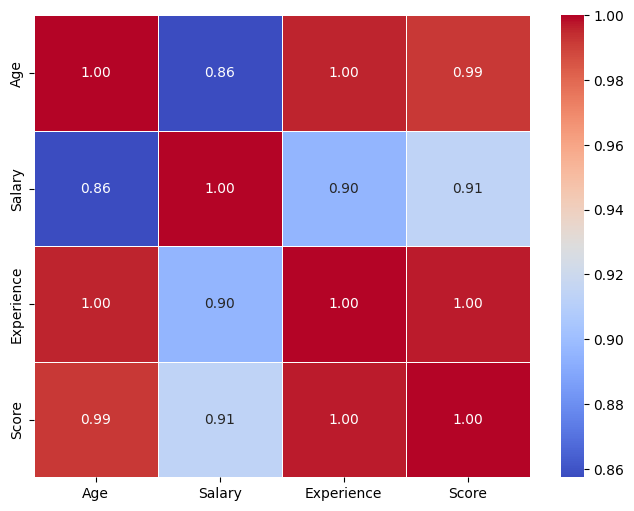

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt = '.2f',
    linewidths= 0.5
)

In [ ]:
PEARSON CORRELATION

In [ ]:
import pandas as pd
data = {
    'Age': [22,25,47,52,46],
    'Salary': [10000,20000,30000,40000,50000],
    'Experience': [1,3,20,25,22]
}
df = pd.DataFrame(data)

corr = df.corr()

print(corr)

                 Age    Salary  Experience
Age         1.000000  0.857381    0.995855
Salary      0.857381  1.000000    0.895477
Experience  0.995855  0.895477    1.000000


In [ ]:
CORREALATION BETWEEN TWO SPECIFIC COLUMNS

In [ ]:
corr_value = df['Age'].corr(df['Experience'])
print(corr_value)

0.9958551906766326


In [ ]:
corr_valuee = df['Age'].corr(df['Salary'])
print(corr_valuee)

0.8573808571077773


PEARSON CORREALATION USING NUMPY

In [ ]:
import numpy as np

x = np.array([2,4,6,8,10])
y = np.array([40,60,80,90,95])

corr = np.corrcoef(x,y)
print(corr)

[[1.         0.97072534]
 [0.97072534 1.        ]]


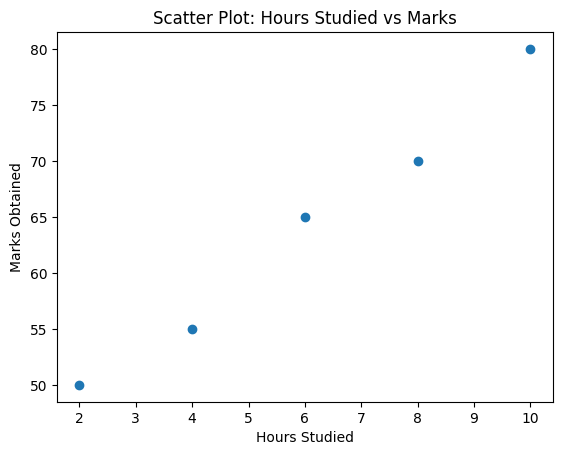

In [ ]:
import matplotlib.pyplot as plt

hours = [2, 4, 6, 8, 10]
marks = [50, 55, 65, 70, 80]

plt.scatter(hours, marks)
plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.title("Scatter Plot: Hours Studied vs Marks")

plt.show()


In [ ]:
import pandas as pd

data = {
    'Hours_Studied': [2, 4, 6, 8, 10],
    'Marks': [50, 55, 65, 75, 85]
}

df = pd.DataFrame(data)
print(df)



   Hours_Studied  Marks
0              2     50
1              4     55
2              6     65
3              8     75
4             10     85


In [ ]:
from sklearn.linear_model import LinearRegression

x = df[['Hours_Studied']]
y = df['Marks']

model = LinearRegression()
model.fit(x, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 39.0
Slope: 4.5


In [ ]:
df['Predicted_Marks'] = model.predict(x)
print(df)

   Hours_Studied  Marks  Predicted_Marks
0              2     50             48.0
1              4     55             57.0
2              6     65             66.0
3              8     75             75.0
4             10     85             84.0


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, df['Predicted_Marks'])
r2 = r2_score(y, df['Predicted_Marks'])

print("Mean squared error:", mse)
print("R2:", r2)

Mean squared error: 2.0
R2: 0.9878048780487805


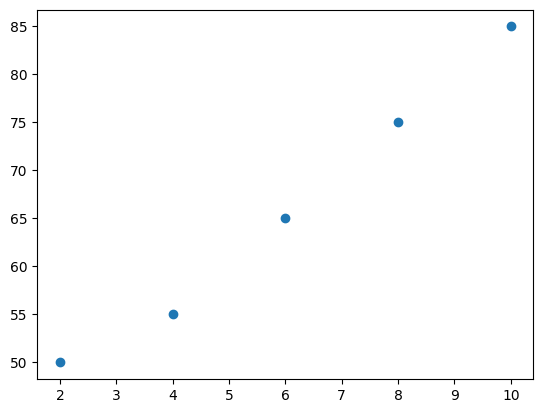

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Hours_Studied'],df['Marks'])
plt.plot(df['Hours_Studied'],df['Predicted_Marks'],color='red')
